In [2]:
!pip install --no-warn-conflicts \
    "tensorflow==2.20.0" \
    "keras>=3.0.0" \
    "protobuf>=5.0.0,<6.0.0" \
    "tf-keras==2.20.0"
!pip install pillow opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 738.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 13.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.1
    Uninstalling protobuf-7.35.1:
      Successfully uninstalled protobuf-7.35.1
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.21.0
    Uninstalling tensorflow-2.21.0:
      Successfully uninstalled tensorflow-2.21.0


In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

MODEL_PATH = "best_model.keras"
IMAGE_PATH = "02.jpg"

print("Đang tải mô hình, vui lòng đợi...")
model = keras.models.load_model(MODEL_PATH)
print("Tải mô hình thành công!")

class_mapping = {
    0: "Incorrect Mask (MC)",
    1: "Incorrect Mask (MMC)",
    2: "With Mask (Complex)",
    3: "With Mask (Simple)",
    4: "Without Mask (Complex)",
    5: "Without Mask (Simple)"
}

class_colors = {
    0: "orange",
    1: "darkorange",
    2: "green",
    3: "limegreen",
    4: "red",
    5: "darkred"
}

TensorFlow Version: 2.20.0
Keras Version: 3.14.1
Đang tải mô hình, vui lòng đợi...
Tải mô hình thành công!


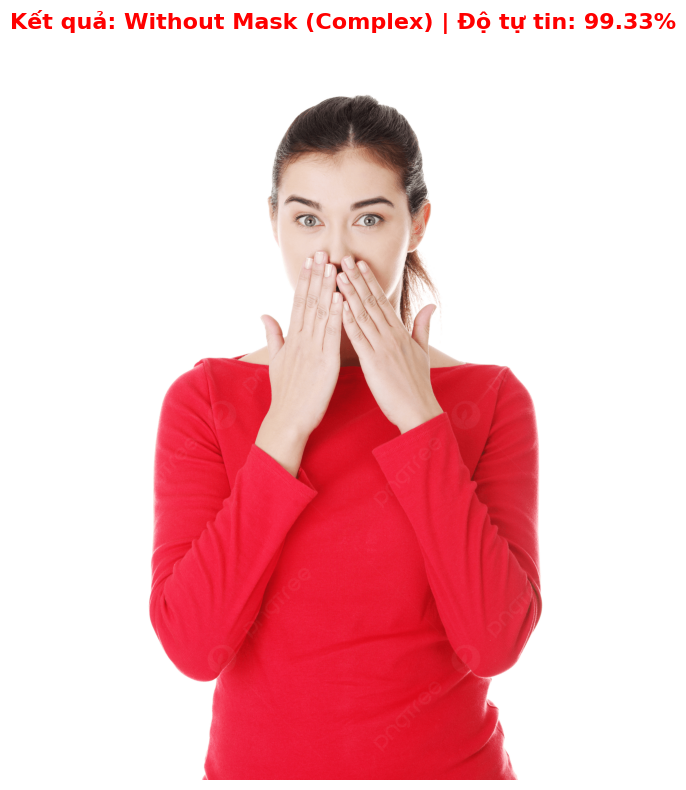

In [14]:
def predict_and_display(image_path, ai_model):
    img = cv2.imread(image_path)
    if img is None:
        print(f"[LỖI] Không tìm thấy hoặc không thể đọc ảnh: {image_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    resized_img = cv2.resize(img_rgb, (224, 224))

    preprocessed_img = keras.applications.mobilenet_v2.preprocess_input(resized_img.astype(np.float32))
    input_tensor = np.expand_dims(preprocessed_img, axis=0)


    predictions = ai_model.predict(input_tensor, verbose=0)[0]
    class_idx = np.argmax(predictions)
    confidence = predictions[class_idx]
    label = class_mapping[class_idx]
    color = class_colors[class_idx]


    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)

    title_text = f"Kết quả: {label} | Độ tự tin: {confidence*100:.2f}%"
    plt.title(title_text, color=color, fontsize=16, fontweight='bold', pad=15)

    plt.axis('off')
    plt.tight_layout()
    plt.show()

predict_and_display(IMAGE_PATH, model)